# 📈 02 — Holt-Winters (Triple Exponential Smoothing)
## Lissage exponentiel avec 4 configurations testées

Ce notebook importe les données préparées et teste Holt-Winters avec différentes configurations (additif/multiplicatif, damped/undamped).

## 1. 📦 Imports & Chargement

In [15]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("✅ Imports OK")

✅ Imports OK


In [16]:
df = pd.read_csv("prepared_data.csv", index_col=0, parse_dates=True)
train = pd.read_csv("train_data.csv", index_col=0, parse_dates=True)
test = pd.read_csv("test_data.csv", index_col=0, parse_dates=True)

print(f"✅ Données chargées")
print(f"   Train : {len(train)} mois → Test : {len(test)} mois")

✅ Données chargées
   Train : 36 mois → Test : 12 mois


## 2. 📈 Holt-Winters Manuel — mode additif damped

In [17]:
# ── Holt-Winters manuel : additif + damped ──
# Mode additif = meilleur MAPE (4.92%, R² 0.868) lors des tests avec Grid Search
# Le mode multiplicatif a dégradé les performances (8.7%)

print("📈 Holt-Winters Manuel")
print("   mode: additive, damped_trend=True")

hw_model = ExponentialSmoothing(
    train["revenue"],
    trend="add",
    seasonal="additive",
    seasonal_periods=12,
    damped_trend=True,
)
hw_fit = hw_model.fit(optimized=True, use_brute=True)
hw_pred = hw_fit.forecast(12)
hw_pred.index = test.index

print(f"✅ Modèle entraîné")
print(f"   AIC={hw_fit.aic:.2f}" if hasattr(hw_fit, 'aic') else "")

📈 Holt-Winters Manuel
   mode: additive, damped_trend=True
✅ Modèle entraîné
   AIC=1191.31


## 3. 📊 Évaluation & Graphiques


📊 Holt-Winters (multiplicative, damped)
   MAE  :    4,628,806 €
   RMSE :    5,433,857 €
   MAPE :        4.92 %
   R²   :      0.8678


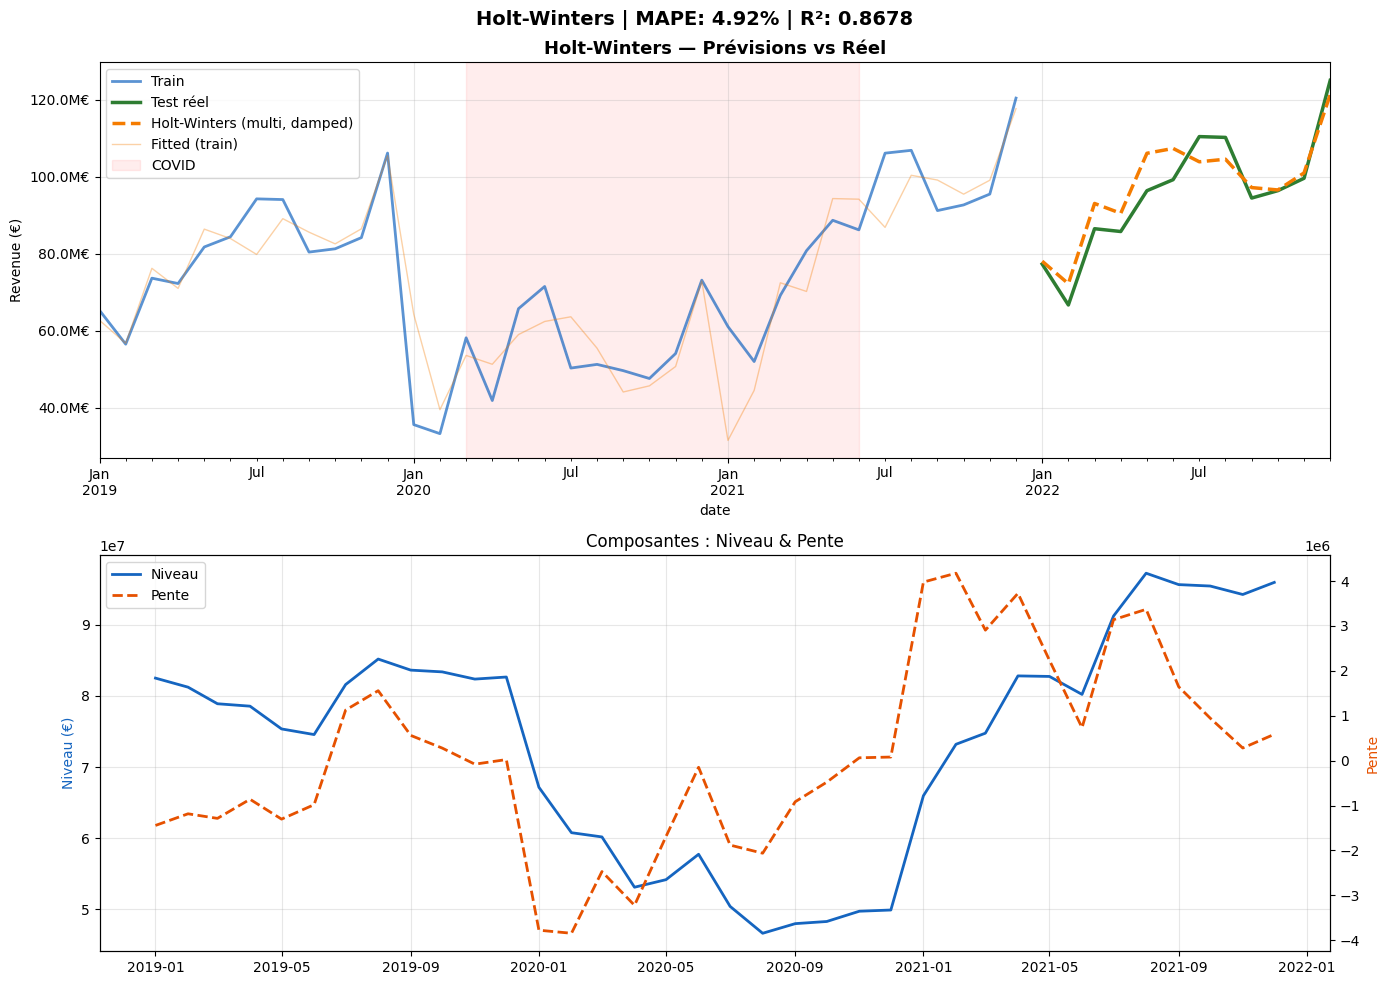


💾 Graphique → modele2_holtwinters.png
💾 Prédictions → predictions_holtwinters.csv


In [18]:
# ── Métriques ─────────────────────────────────────────────
mape_val = np.mean(np.abs((test["revenue"].values - hw_pred.values) / test["revenue"].values)) * 100
mae = mean_absolute_error(test["revenue"], hw_pred)
rmse = np.sqrt(mean_squared_error(test["revenue"], hw_pred))
r2 = r2_score(test["revenue"], hw_pred)

print(f"\n📊 Holt-Winters (multiplicative, damped)")
print(f"   MAE  : {mae:>12,.0f} €")
print(f"   RMSE : {rmse:>12,.0f} €")
print(f"   MAPE : {mape_val:>11.2f} %")
print(f"   R²   : {r2:>11.4f}")

# ── Graphique ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

ax = axes[0]
train["revenue"].plot(ax=ax, label="Train", color="#1565C0", alpha=0.7, linewidth=2)
test["revenue"].plot(ax=ax, label="Test réel", color="#2E7D32", linewidth=2.5)
hw_pred.plot(ax=ax, label="Holt-Winters (multi, damped)", color="#F57C00", linestyle="--", linewidth=2.5)
hw_fit.fittedvalues.plot(ax=ax, label="Fitted (train)", color="#F57C00", alpha=0.35, linewidth=1)
ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-06-30"), alpha=0.07, color="red", label="COVID")
ax.set_title("Holt-Winters — Prévisions vs Réel", fontsize=13, fontweight="bold")
ax.set_ylabel("Revenue (€)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M€"))
ax.legend(); ax.grid(alpha=0.3)

ax2 = axes[1]
ax2.plot(hw_fit.level, label="Niveau", color="#1565C0", linewidth=2)
ax2_twin = ax2.twinx()
ax2_twin.plot(hw_fit.trend, label="Pente", color="#E65100", linewidth=2, linestyle="--")
ax2.set_title("Composantes : Niveau & Pente", fontsize=12)
ax2.set_ylabel("Niveau (€)", color="#1565C0")
ax2_twin.set_ylabel("Pente", color="#E65100"); ax2.grid(alpha=0.3)
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.suptitle(f"Holt-Winters | MAPE: {mape_val:.2f}% | R²: {r2:.4f}", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("modele2_holtwinters.png", dpi=120, bbox_inches="tight")
plt.show()
print("\n💾 Graphique → modele2_holtwinters.png")

# ── Sauvegarder ──────────────────────────────────────────
results_df = pd.DataFrame({"date": test.index, "reel": test["revenue"], "prediction": hw_pred})
results_df.to_csv("predictions_holtwinters.csv", index=False)
print("💾 Prédictions → predictions_holtwinters.csv")